# Reconocimiento de Señales de Tránsito — GTSRB - Reto 3

## Descripción
Una startup que desarrolla un sistema de asistencia a la conducción necesita un módulo de
visión que reconozca señales de tránsito en tiempo real. El modelo debe ser pequeño y rápido
(correrá en un dispositivo embebido), pero altamente preciso: una señal mal interpretada
puede causar un accidente.

## Objetivo
Entrenar una CNN que clasifique correctamente las 43 categorías
de señales de tránsito del dataset GTSRB.



### Importación de librerias y fijación de semillas

Se importan todas las librerías necesarias y se fijan las semillas para garantizar reproducibilidad en Python, NumPy y TensorFlow.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import random
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Fase 1 — Ingesta

Se descarga el dataset GTSRB desde Kaggle usando kagglehub
y se muestra una imagen de ejemplo para verificar que
la descarga fue exitosa.

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset downloaded to: /kaggle/input/gtsrb-german-traffic-sign
Displaying example image: /kaggle/input/gtsrb-german-traffic-sign/Meta/37.png


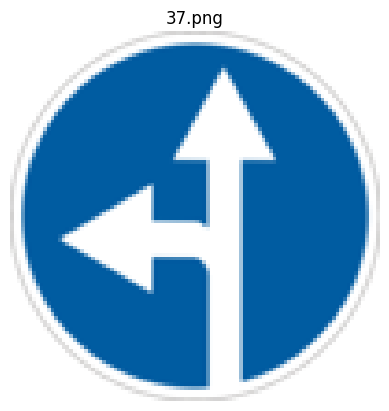

In [2]:
import kagglehub
import os
from PIL import Image
import matplotlib.pyplot as plt

# Download the latest version of the German Traffic Sign Recognition Benchmark dataset
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

# List contents of the downloaded dataset path to show its structure
print(f"Dataset downloaded to: {path}")

# Find and display an example image (assuming common image dataset structure)
image_found = False
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(root, file)
            image_found = True
            break
    if image_found:
        break

if image_found:
    print(f"Displaying example image: {image_path}")
    img = Image.open(image_path)
    plt.imshow(img)
    plt.title(os.path.basename(image_path))
    plt.axis('off') # Hide axes ticks
    plt.show()
else:
    print("No image files found in the dataset directory.")

### Estructura del dataset

Se verifica la división interna del dataset, encontrando
tres carpetas: Train (39.209 imágenes), Test (12.631 imágenes)
y Meta (45 archivos).

In [3]:
import os

print("Estructura del dataset\n")
for carpeta in ['Train', 'Test', 'Meta']:
    ruta = os.path.join(path, carpeta)
    if os.path.exists(ruta):
        total = sum(
            len(files) for _, _, files in os.walk(ruta)
        )
        print(f"{carpeta}: {total} archivos")

Estructura del dataset

Train: 39209 archivos
Test: 12631 archivos
Meta: 45 archivos


## Fase 2 — Exploración de datos (EDA)

### Muestra aleatoria de imágenes

Se visualizan 9 imágenes aleatorias de la carpeta Train/
con el fin de conocer cómo son las imágenes con las que se trabajará.

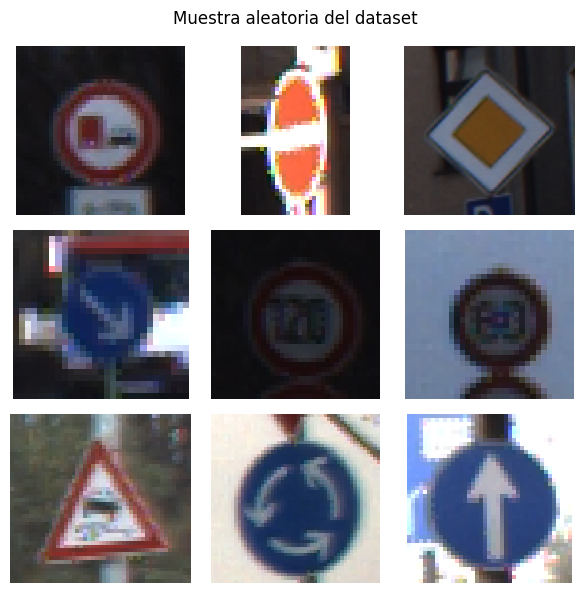

In [4]:

random.seed(42)

imagenes = []
for root, dirs, files in os.walk(os.path.join(path, "Train")):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            imagenes.append(os.path.join(root, file))

muestra = random.sample(imagenes, 9)

plt.figure(figsize=(6,6))
for i, img_path in enumerate(muestra):
    img = Image.open(img_path)
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle("Muestra aleatoria del dataset")
plt.tight_layout()
plt.show()

### Distribución de clases

La gráfica muestra cómo están distribuidas las imágenes dentro
de las 43 categorías. Se puede observar que existe variación,
con algunas clases con ~200 imágenes y otras con más de 2.000.

Se decidió no eliminar ni balancear artificialmente las imágenes, ya que la distribución original del dataset representa escenarios reales de tránsito, donde algunas señales aparecen con mayor frecuencia que otras. Sin embargo, para reducir el impacto del desbalance, se aaplicará Data Augmentation durante el entrenamiento en las clases con menor cantidad de imágenes.

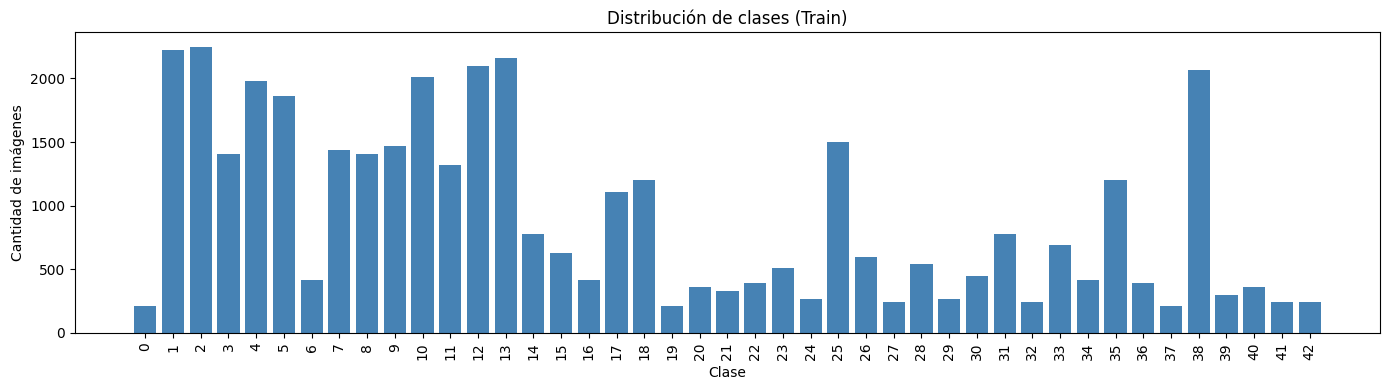

In [5]:
train_path = os.path.join(path, "Train")

conteo = {}
for clase in os.listdir(train_path):
    ruta_clase = os.path.join(train_path, clase)
    if os.path.isdir(ruta_clase):
        conteo[int(clase)] = len(os.listdir(ruta_clase))

conteo = dict(sorted(conteo.items()))

plt.figure(figsize=(14, 4))
plt.bar([str(k) for k in conteo.keys()], list(conteo.values()), color='steelblue')
plt.xticks(rotation=90)
plt.title("Distribución de clases (Train)")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.show()

### Íconos de las 43 categorías

Para comprender la información con la que se está trabajando, se visualizan los íconos de cada una de las 43 categorías
del dataset GTSRB. Estas imágenes provienen de la carpeta Meta/
y no se usan en el entrenamiento ni en la evaluación del modelo.

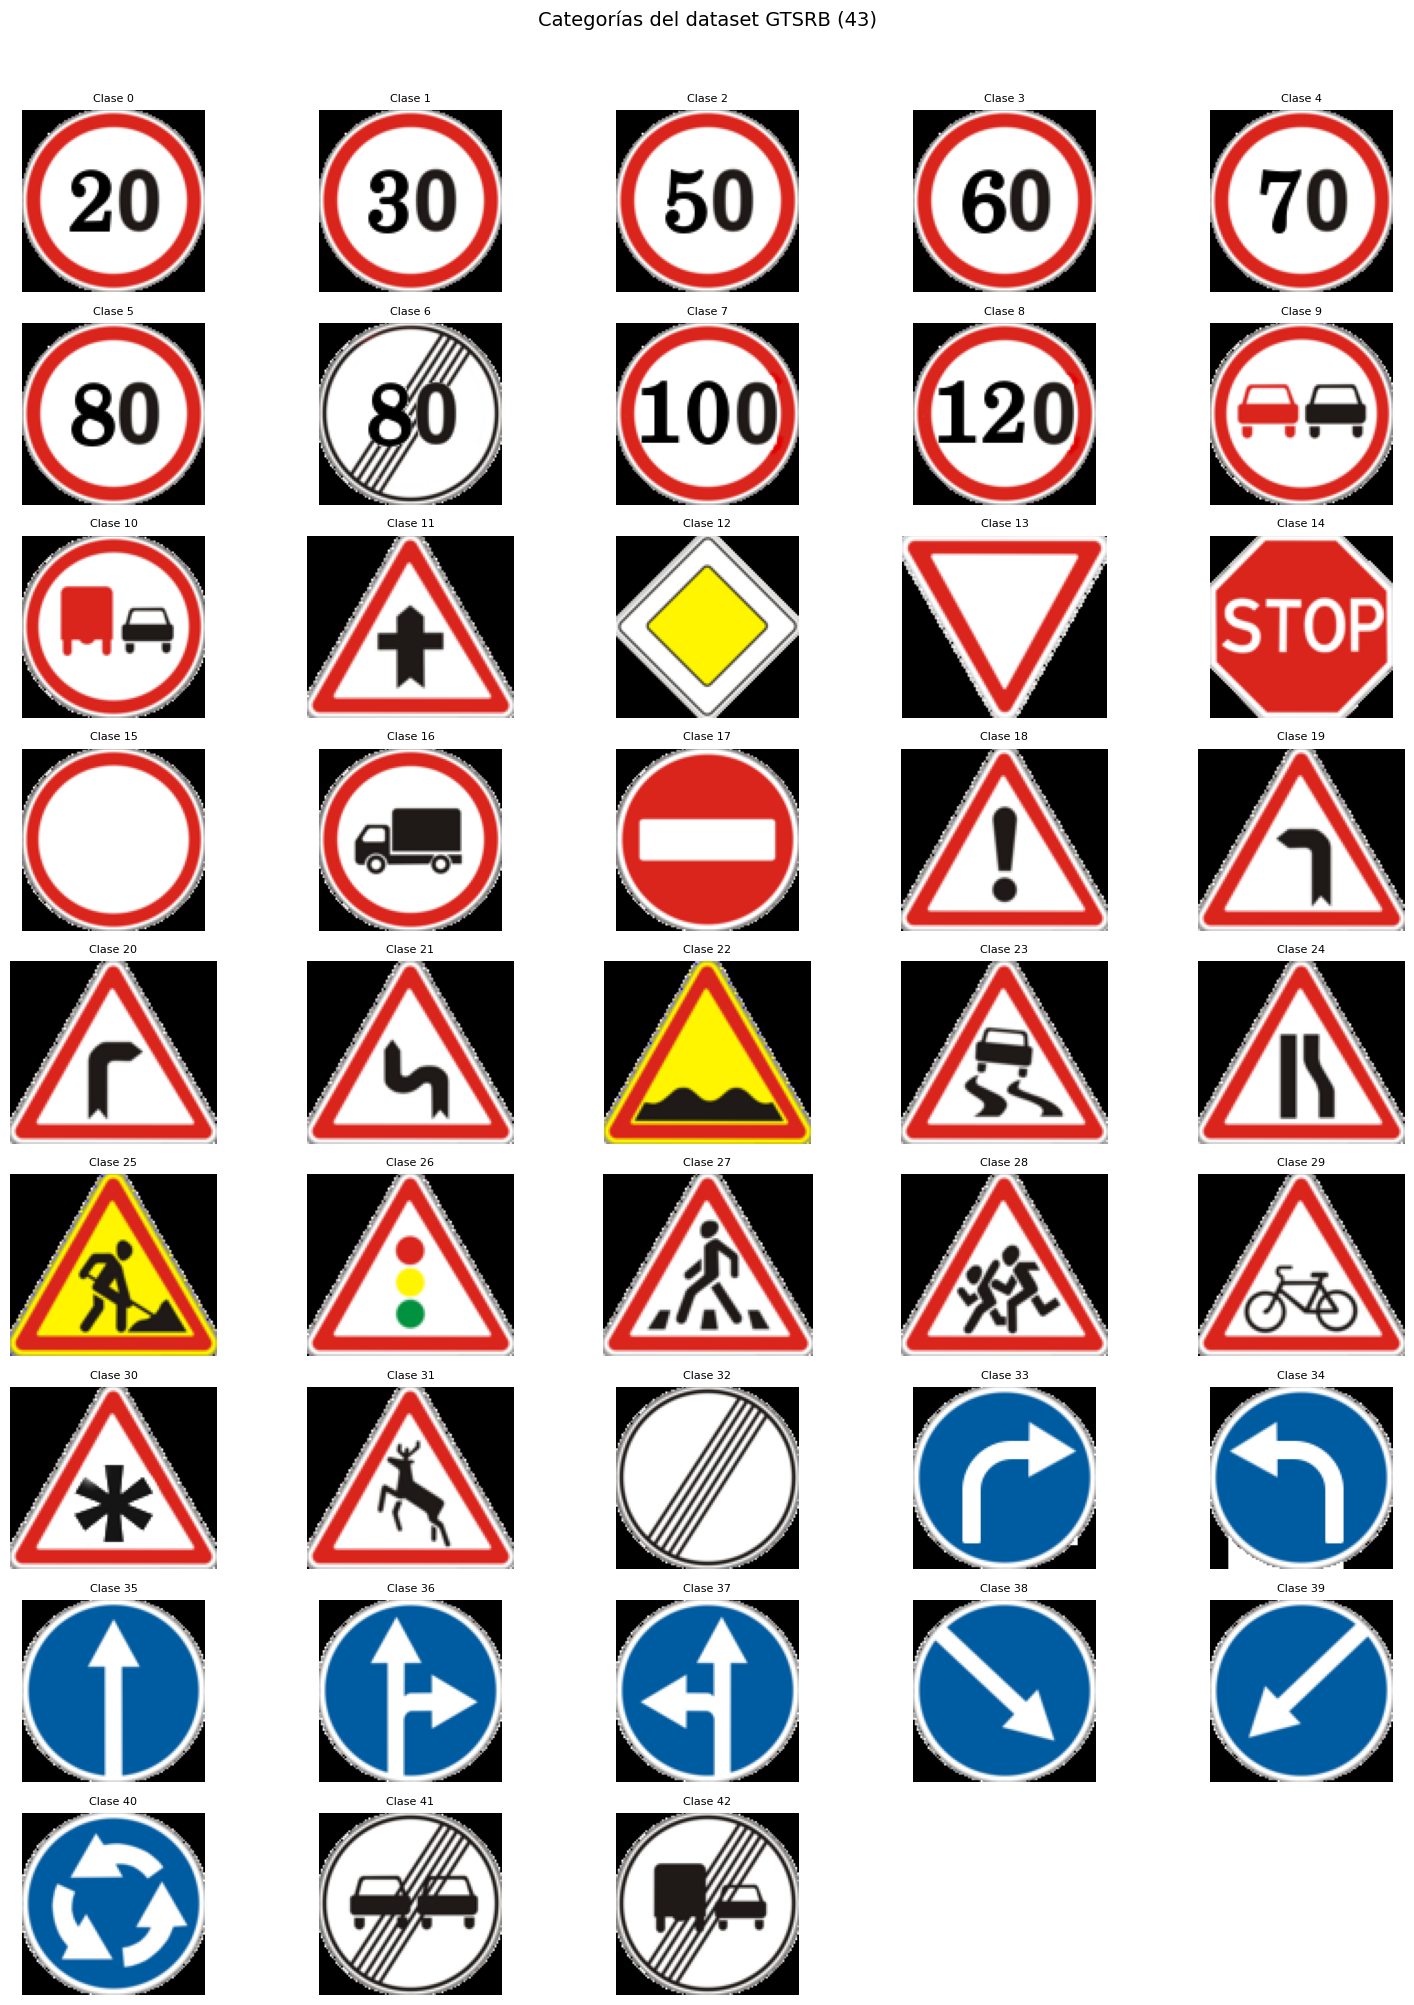

In [6]:
plt.figure(figsize=(15, 20))
for clase in range(43):
    icono_path = os.path.join(path, "Meta", f"{clase}.png")
    icono = cv2.imread(icono_path)
    icono = cv2.cvtColor(icono, cv2.COLOR_BGR2RGB)

    plt.subplot(9, 5, clase + 1)
    plt.imshow(icono)
    plt.title(f"Clase {clase}", fontsize=8)
    plt.axis("off")

plt.suptitle("Categorías del dataset GTSRB (43)", fontsize=14, y=1.00)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

### Distribución de tamaños originales

Se visualiza la distribución de anchos y altos originales
de las imágenes.

La mayoría se encuentra entre 25px y 50px,
con un rango que va desde 25px hasta 243px de ancho y
225px de alto.

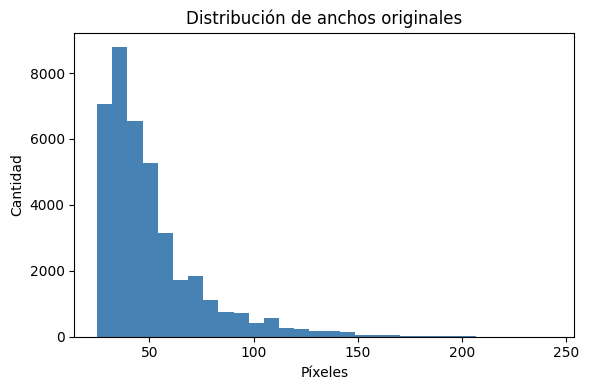

In [7]:
anchos, altos = [], []

for root, dirs, files in os.walk(train_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img = cv2.imread(os.path.join(root, file))
            if img is not None:
                altos.append(img.shape[0])
                anchos.append(img.shape[1])

plt.figure(figsize=(6, 4))
plt.hist(anchos, bins=30, color='steelblue')
plt.title("Distribución de anchos originales")
plt.xlabel("Píxeles")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

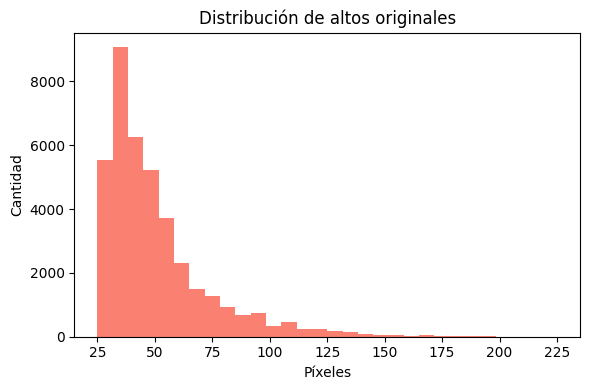

Ancho mínimo: 25px | máximo: 243px
Alto  mínimo: 25px  | máximo: 225px


In [8]:
plt.figure(figsize=(6, 4))
plt.hist(altos, bins=30, color='salmon')
plt.title("Distribución de altos originales")
plt.xlabel("Píxeles")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

print(f"Ancho mínimo: {min(anchos)}px | máximo: {max(anchos)}px")
print(f"Alto  mínimo: {min(altos)}px  | máximo: {max(altos)}px")

## Fase 3 — Limpieza

### Imágenes ilegibles (nulos)

Se verifica que todas las imágenes de la carpeta Train/
puedan ser leídas correctamente.

**Resultado:** 39.209 imágenes legibles, 0 ilegibles.

In [9]:
imagenes_legibles = []
imagenes_ilegibles = []

for root, dirs, files in os.walk(train_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            ruta = os.path.join(root, file)
            img = cv2.imread(ruta)
            if img is None:
                imagenes_ilegibles.append(ruta)
            else:
                imagenes_legibles.append(ruta)

print(f"Imágenes legibles:   {len(imagenes_legibles)}")
print(f"Imágenes ilegibles:  {len(imagenes_ilegibles)}")

Imágenes legibles:   39209
Imágenes ilegibles:  0


### Duplicados

Se busca si existen imágenes con el mismo nombre de archivo
dentro del dataset, lo que indicaría datos repetidos
que podrían sesgar el entrenamiento.

**Resultado:** No se encuentran duplicados.

In [10]:
nombres_vistos = set()
duplicados = []

for ruta in imagenes_legibles:
    nombre = os.path.basename(ruta)
    if nombre in nombres_vistos:
        duplicados.append(ruta)
    else:
        nombres_vistos.add(nombre)

print(f"Imágenes duplicadas: {len(duplicados)}")

Imágenes duplicadas: 0


### Detección de outliers de tamaño

Se aplica el método IQR (rango intercuartílico), que identifica
como outliers los valores que superan 1.5 veces el rango entre
el percentil 25 y 75, adaptado a imágenes usando el tamaño
en píxeles² como variable.

**Resultado:** 3.950 imágenes fuera del rango IQR.

In [11]:
tamaños = []
for ruta in imagenes_legibles:
    img = cv2.imread(ruta)
    tamaños.append(img.shape[0] * img.shape[1])

tamaños = np.array(tamaños)
q1 = np.percentile(tamaños, 25)
q3 = np.percentile(tamaños, 75)
iqr = q3 - q1
outliers = np.sum((tamaños < q1 - 1.5 * iqr) | (tamaños > q3 + 1.5 * iqr))

print(f"Outliers de tamaño: {outliers}")

Outliers de tamaño: 3950


### Análisis de outliers de tamaño

Se calculan los límites del método IQR para entender
el rango de tamaños del dataset:

- **Límite inferior:** -2.065 píxeles²
- **Límite superior:** 6.615 píxeles²
- **Tamaño mínimo real:** 625 píxeles²
- **Tamaño máximo real:** 54.675 píxeles²

El tamaño máximo real supera ampliamente el límite superior
del IQR, lo que confirma la alta variabilidad de resoluciones
en el dataset.
**Decisión:** No se eliminarán. Serán redimensionadas a
32×32 píxeles en la fase de preprocesamiento.

In [12]:
q1_val = np.percentile(tamaños, 25)
q3_val = np.percentile(tamaños, 75)
iqr_val = q3_val - q1_val

mascara_outliers = (tamaños < q1_val - 1.5 * iqr_val) | (tamaños > q3_val + 1.5 * iqr_val)

print(f"Q1: {q1_val:.0f} píxeles²")
print(f"Q3: {q3_val:.0f} píxeles²")
print(f"IQR: {iqr_val:.0f}")
print(f"Límite inferior: {q1_val - 1.5 * iqr_val:.0f} píxeles²")
print(f"Límite superior: {q3_val + 1.5 * iqr_val:.0f} píxeles²")
print(f"\nTamaño mínimo encontrado: {tamaños.min()} píxeles²")
print(f"Tamaño máximo encontrado: {tamaños.max()} píxeles²")

Q1: 1190 píxeles²
Q3: 3360 píxeles²
IQR: 2170
Límite inferior: -2065 píxeles²
Límite superior: 6615 píxeles²

Tamaño mínimo encontrado: 625 píxeles²
Tamaño máximo encontrado: 54675 píxeles²


## Fase 4 — Preprocesamiento

### Carga y redimensionamiento de imágenes

Se cargan las 39.209 imágenes de la carpeta `Train/`,
aplicando dos transformaciones:

- **BGR a RGB:** OpenCV carga las imágenes en formato BGR
  por defecto, por lo que se convierten a RGB para representar
  correctamente los colores.

- **Redimensionamiento a 32×32:** Se estandariza el tamaño
  de todas las imágenes para que la CNN pueda procesarlas
  en lotes. Esto reduce la variabilidad de tamaños detectada
  en la fase de limpieza.

**Resultado:** se obtiene un array con forma `(39.209, 32, 32, 3)`,
donde 39.209 corresponde al número de imágenes, 32×32 al tamaño
de cada imagen y 3 a los canales RGB.

In [13]:
IMG_SIZE = 32
X = []
y = []

for clase in os.listdir(train_path):
    ruta = os.path.join(train_path, clase)
    if os.path.isdir(ruta):
        for img_name in os.listdir(ruta):
            img_path = os.path.join(ruta, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(int(clase))

X = np.array(X)
y = np.array(y)
print(f"Total imágenes cargadas: {len(X)}")
print(f"Shape: {X.shape}")

Total imágenes cargadas: 39209
Shape: (39209, 32, 32, 3)


### Normalización

Se divide cada píxel entre 255 para que todos los valores
queden en un rango entre 0 y 1, en lugar de entre 0 y 255.
Esto ayuda al modelo a aprender más fácilmente, ya que reduce
la escala de los datos y estabiliza el entrenamiento.

**Resultado:** valor mínimo 0.0, valor máximo 1.0.

In [14]:
X = X / 255.0
print(f"Valor mínimo: {X.min()}")
print(f"Valor máximo: {X.max()}")

Valor mínimo: 0.0
Valor máximo: 1.0


### Codificación de etiquetas (One-Hot Encoding)

Se convierten las etiquetas numéricas (0-42) a vectores
binarios de 43 posiciones usando one-hot encoding.
Cada posición representa una clase y solo la posición
correspondiente a la clase real vale 1, el resto vale 0.

Esto para que la función de pérdida
categorical_crossentropy funcione correctamente.

**Resultado:** array de forma (39.209, 43).

In [15]:
y_encoded = to_categorical(y, 43)
print(f"Shape de y_encoded: {y_encoded.shape}")
print(f"Ejemplo de etiqueta one-hot: {y_encoded[0]}")

Shape de y_encoded: (39209, 43)
Ejemplo de etiqueta one-hot: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### División train/val/test

Se dividen los datos en tres conjuntos usando random_state=42
para garantizar reproducibilidad:

- **Train (60% — 23.525 imágenes):** el modelo aprende con estos datos.
- **Val (20% — 7.842 imágenes):** monitorea el entrenamiento y
  activa el EarlyStopping si el modelo deja de mejorar.
- **Test (20% — 7.842 imágenes):** se usa una sola vez al final
  para medir el rendimiento real del modelo sobre datos nunca vistos.

In [16]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)

print(f"Train: {X_train.shape[0]}")
print(f"Val:   {X_val.shape[0]}")
print(f"Test:  {X_test.shape[0]}")

Train: 23525
Val:   7842
Test:  7842


## Fase 5 — Modelado

Se utiliza una CNN en lugar de arquitecturas como ANN, RNN/LSTM
o Transformers, ya que está diseñada específicamente para trabajar
con imágenes, detectando bordes, formas y texturas, características
clave para distinguir señales de tránsito.

### Arquitectura de la CNN

La red está compuesta por 3 bloques convolucionales con filtros
crecientes (32 → 64 → 128), lo que permite extraer características
de bajo a alto nivel de complejidad. Posteriormente, se incluye una
capa densa para la clasificación final.

**Decisiones de diseño:**
- **BatchNormalization:** estabiliza el entrenamiento al normalizar
  las activaciones entre capas.
- **MaxPooling2D:** reduce la dimensión espacial conservando las
  características más relevantes.
- **Dropout (0.5):** desactiva aleatoriamente el 50% de las neuronas
  durante el entrenamiento para reducir el sobreajuste.
- **Data Augmentation:** genera variaciones de las imágenes mediante
  rotaciones, zoom y desplazamientos, mejorando la generalización y
  reduciendo el impacto del desbalance de clases.
- **Softmax en la salida:** convierte las salidas en probabilidades
  para las 43 clases.

**Total de parámetros entrenables:** 164.651

In [17]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(43, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,843 (643.92 KB)

 Trainable params: 164,651 (643.17 KB)

 Non-trainable params: 192 (768.00 B)

Con **164.651 parámetros entrenables** y un tamaño de 643.17 KB, el modelo es lo suficientemente ligero para su ejecución en dispositivos embebidos.

### Compilación del modelo

Se compila el modelo con los siguientes parámetros:

- **Optimizador Adam:** optimizador adaptativo ampliamente utilizado, con una convergencia generalmente más rápida que el descenso de gradiente estocástico (SGD).
- **Loss categorical_crossentropy:** función de pérdida estándar para problemas de clasificación multiclase con etiquetas en formato one-hot.
- **Métrica accuracy:** mide el porcentaje de imágenes clasificadas correctamente.

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Entrenamiento

Se entrena el modelo con los siguientes hiperparámetros:

- **Epochs 15:** número máximo de ciclos de entrenamiento.
- **Batch size 32:** número de imágenes procesadas por iteración.
- **EarlyStopping patience=5:** detiene el entrenamiento si
  la pérdida de validación no mejora en 5 épocas consecutivas,
  restaurando los mejores pesos encontrados.
- **Data Augmentation:** se aplican transformaciones aleatorias
  (rotación ±10°, zoom 10%, desplazamiento horizontal y vertical 10%)
  para generar variedad artificial y atacar el desbalance de clases
  detectado en el EDA.

**Resultado:** el modelo completó las 15 épocas con una
accuracy de validación del 98.95%, lo que indica que aprendió
a generalizar correctamente sin sobreajuste.

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=15,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.4386 - loss: 1.9582 - val_accuracy: 0.8528 - val_loss: 0.5474
Epoch 2/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.8053 - loss: 0.6066 - val_accuracy: 0.9294 - val_loss: 0.2144
Epoch 3/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.8934 - loss: 0.3392 - val_accuracy: 0.9617 - val_loss: 0.1399
Epoch 4/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9270 - loss: 0.2374 - val_accuracy: 0.9550 - val_loss: 0.1467
Epoch 5/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9417 - loss: 0.1938 - val_accuracy: 0.9792 - val_loss: 0.0753
Epoch 6/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9549 - loss: 0.1480 - val_accuracy: 0.9779 - val_loss: 0.0703
Epoch 7/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9576 - loss: 0.1450 - val_accuracy: 0.9674 - val_loss: 0.1192
Epoch 8/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9657 - loss: 0.1166 - 

## Fase 6 — Evaluación

### Métricas en test

Se evalúa el modelo sobre las 7.842 imágenes del conjunto
de prueba, que nunca fueron vistas durante el entrenamiento.

- **Loss: 0.0411**
- **Accuracy: 98.87%**

El modelo clasifica correctamente el 98.87% de las señales
de tránsito.

In [20]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Loss en test:     {loss:.4f}")
print(f"Accuracy en test: {acc:.4f}")

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9887 - loss: 0.0411
Loss en test:     0.0411
Accuracy en test: 0.9887


### Comparación con baseline

El baseline consiste en predecir siempre la clase más
frecuente del dataset, sin aprender nada.

- **Baseline accuracy: 5.66%**
- **Modelo CNN accuracy: 98.87%**
- **Mejora sobre baseline: 93.2%**

El modelo CNN supera al baseline en 93.2 puntos porcentuales,
lo que demuestra que la red aprendió patrones reales y no
simplemente memorizó la clase más común.

In [21]:
clase_mas_frecuente = np.bincount(np.argmax(y_train, axis=1)).argmax()
baseline_acc = np.mean(np.argmax(y_test, axis=1) == clase_mas_frecuente)
print(f"Baseline accuracy: {baseline_acc:.4f}")
print(f"Modelo CNN accuracy: {acc:.4f}")
print(f"Mejora sobre baseline: {(acc - baseline_acc)*100:.1f}%")

Baseline accuracy: 0.0566
Modelo CNN accuracy: 0.9887
Mejora sobre baseline: 93.2%


### Curvas de aprendizaje

Se visualiza la evolución del *loss* y la *accuracy* durante
el entrenamiento para analizar posibles casos de sobreajuste o subajuste.

**Loss:** tanto el conjunto de entrenamiento como el de validación
disminuyen de forma consistente, lo que indica que el modelo está
aprendiendo de manera adecuada.

**Accuracy:** val supera ligeramente a train durante el entrenamiento
y ambas convergen hacia valores altos al final, lo que confirma
que el modelo generaliza bien sin memorizar los datos de entrenamiento.

En general, no se observan señales significativas de sobreajuste.

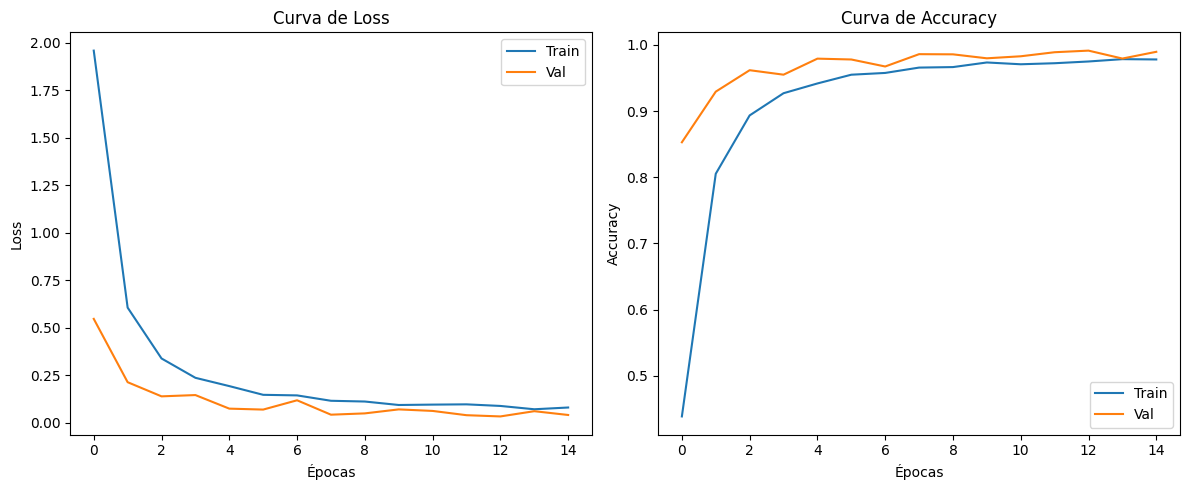

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Curva de Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Curva de Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Predicciones sobre el conjunto de prueba

El modelo genera probabilidades para cada una de las 43
clases por imagen. Se toma la clase con mayor probabilidad
como predicción final y se convierten las etiquetas reales
de one-hot a números para poder compararlas con las predicciones.

In [23]:
pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)
true_classes = np.argmax(y_test, axis=1)

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


### Reporte de clasificación

Se evalúa el rendimiento del modelo por cada una de las 43 clases individualmente.

- **Accuracy global: 99%**
- **Precision, Recall y F1-score promedio: 0.99**

La mayoría de clases alcanza valores perfectos o cercanos a 1.0.
Las clases con menor rendimiento son la 20, 27 y 30 con F1-score
de 0.97, que coinciden con categorías que tienen menor cantidad
de imágenes en el dataset, lo que confirma el impacto del
desbalance de clases mencionado en el EDA.

In [24]:
print(classification_report(true_classes, pred_classes))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        41
           1       0.98      0.98      0.98       444
           2       1.00      0.96      0.98       444
           3       0.98      0.96      0.97       295
           4       1.00      0.99      0.99       396
           5       0.94      0.99      0.96       338
           6       1.00      0.99      0.99        87
           7       1.00      0.99      0.99       324
           8       0.99      1.00      0.99       260
           9       0.99      1.00      1.00       274
          10       0.99      1.00      1.00       417
          11       0.98      1.00      0.99       258
          12       1.00      1.00      1.00       453
          13       1.00      0.99      1.00       431
          14       0.92      1.00      0.96       165
          15       1.00      1.00      1.00       134
          16       1.00      1.00      1.00        72
          17       1.00    

### Visualización de predicciones

Se muestran 9 imágenes del conjunto de prueba con su
etiqueta real y la predicción del modelo. En todos los
casos la predicción coincide con la etiqueta real,
lo que es consistente con el 98.87% de accuracy obtenido.

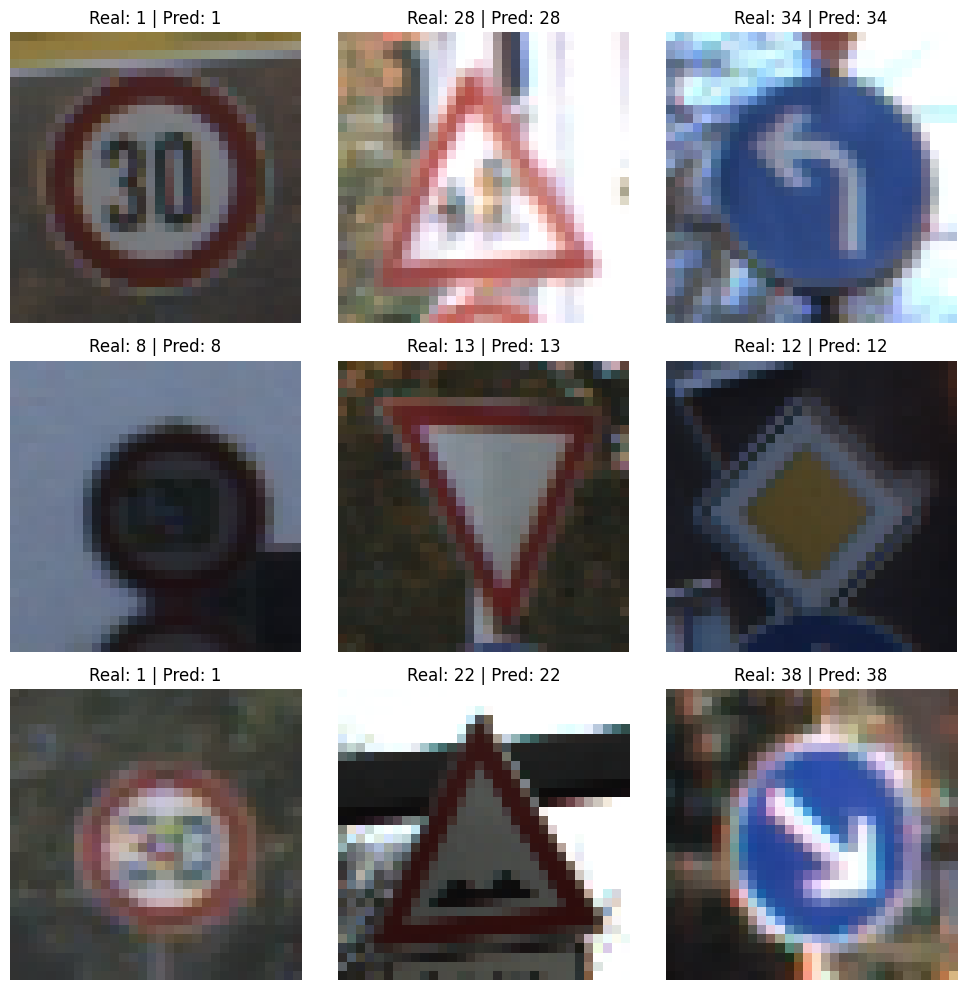

In [25]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i])
    plt.title(f"Real: {true_classes[i]} | Pred: {pred_classes[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Análisis de errores

La matriz de confusión muestra una alta concentración de valores
en la diagonal principal, lo que indica un buen desempeño general
del modelo en la clasificación de las 43 clases.

Los errores se presentan de forma aislada en algunas clases,
reflejando principalmente confusiones entre señales visualmente
similares, especialmente aquellas con formas y patrones de color parecidos.

En general, la cantidad de errores fuera de la diagonal es mínima,
lo que confirma un desempeño alto y consistente del modelo.

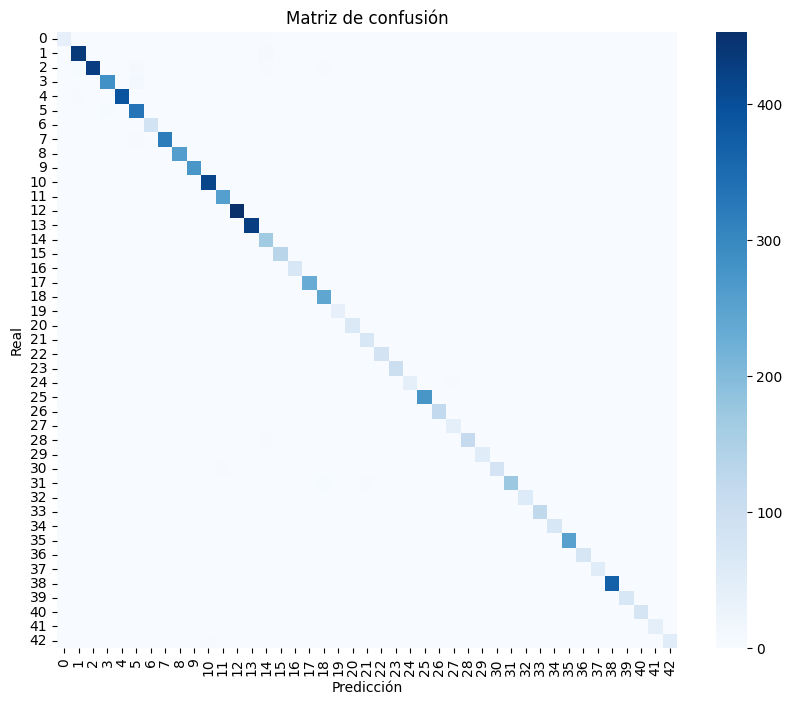

In [26]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues", fmt="d")
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [27]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Loss en test:     {loss:.4f}")
print(f"Accuracy en test: {acc:.4f}")

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9887 - loss: 0.0411
Loss en test:     0.0411
Accuracy en test: 0.9887


### Guardar modelo

Se guarda el modelo entrenado en formato .h5 para
poder reutilizarlo sin necesidad de volver a entrenar.

In [28]:
model.save("cnn_gtsrb.h5")
print("Modelo guardado correctamente.")

Modelo guardado correctamente.


In [29]:
from google.colab import files
files.download("cnn_gtsrb.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Fase 7 — Demostración

Se toma una imagen aleatoria de la carpeta Test/ original
del dataset GTSRB, conjunto que no fue utilizado en ninguna
fase del entrenamiento ni la evaluación del modelo.
Se aplica el mismo preprocesamiento del pipeline y se
realiza la inferencia en vivo.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step


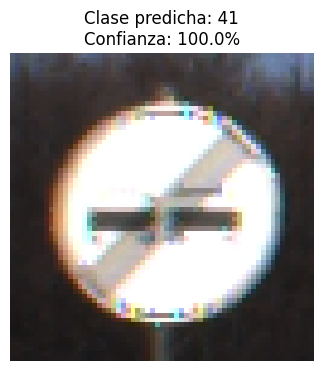

Archivo: 00140.png
Clase predicha: 41
Confianza: 100.0%


In [30]:
test_path = os.path.join(path, "Test")
archivos = [f for f in os.listdir(test_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

random.seed(42)
img_demo_name = random.choice(archivos)
img_demo_path = os.path.join(test_path, img_demo_name)

img_demo = cv2.imread(img_demo_path)
img_demo = cv2.cvtColor(img_demo, cv2.COLOR_BGR2RGB)
img_demo_original = img_demo.copy()
img_demo = cv2.resize(img_demo, (32, 32))
img_array = img_demo / 255.0
img_input = np.expand_dims(img_array, axis=0)

pred = model.predict(img_input)
clase_predicha = np.argmax(pred)
confianza = np.max(pred) * 100

plt.figure(figsize=(4,4))
plt.imshow(img_demo_original)
plt.title(f"Clase predicha: {clase_predicha}\nConfianza: {confianza:.1f}%")
plt.axis("off")
plt.show()

print(f"Archivo: {img_demo_name}")
print(f"Clase predicha: {clase_predicha}")
print(f"Confianza: {confianza:.1f}%")

## Cierre — Limitaciones y siguiente paso

### Limitaciones del modelo
- Puede fallar con imágenes donde la señal ocupa poco
  espacio dentro de la foto.
- Sensible a condiciones de baja iluminación o imágenes borrosas.
- Señales parcialmente tapadas o dañadas pueden clasificarse
  incorrectamente.
- El desbalance de clases afecta levemente el rendimiento
  en categorías con pocas imágenes.

### Siguiente paso para producción
- Integrar un detector de señales que identifique y recorte
  automáticamente la señal dentro de la imagen antes de
  pasarla al clasificador, mejorando el rendimiento en
  escenas reales.
- Desplegar el modelo en un dispositivo embebido y medir
  su velocidad de inferencia en tiempo real.